## Projet : Customer Churn Prediction & Decision Dashboard

**Objectif du projet**

Ce projet vise à **prédire le churn des clients télécom** et à fournir un **outil d’aide à la décision** pour améliorer la rétention client.

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Table clients
clients = df[[
    'customerID',
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents'
]].copy()

clients.rename(columns={'customerID': 'client_id'}, inplace=True)

# Table subscriptions
subscriptions = df[[
    'customerID',
    'tenure',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod',
    'MonthlyCharges',
    'TotalCharges',
    'Churn'
]].copy()

subscriptions.rename(columns={'customerID': 'client_id'}, inplace=True)


In [ ]:
clients.head()

,client_id,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


In [ ]:
subscriptions.head()

,client_id,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,34,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,2,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,45,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,2,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
clients.shape

(7043, 5)

In [ ]:
subscriptions.shape

(7043, 8)

In [ ]:
clients.duplicated().sum()

np.int64(0)

In [ ]:
subscriptions.duplicated().sum()

np.int64(0)

## Étape 3 - Détection des anomalies (CRITIQUE)

In [ ]:
subscriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         7043 non-null   object 
 1   tenure            7043 non-null   int64  
 2   Contract          7043 non-null   object 
 3   PaperlessBilling  7043 non-null   object 
 4   PaymentMethod     7043 non-null   object 
 5   MonthlyCharges    7043 non-null   float64
 6   TotalCharges      7043 non-null   object 
 7   Churn             7043 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 440.3+ KB


### 1. Problème majeur à analyser : TotalCharges

In [ ]:
subscriptions['TotalCharges'].unique()[:20]

array(['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5',
       '1949.4', '301.9', '3046.05', '3487.95', '587.45', '326.8',
       '5681.1', '5036.3', '2686.05', '7895.15', '1022.95', '7382.25',
       '528.35', '1862.9'], dtype=object)

Trouver :

* des chaînes vides " "
* des valeurs non numériques

### 2. Conversion test

In [ ]:
pd.to_numeric(subscriptions['TotalCharges'], errors='coerce')

,TotalCharges
0,29.85
1,1889.50
2,108.15
3,1840.75
4,151.65
...,...
7038,1990.50
7039,7362.90
7040,346.45
7041,306.60


In [ ]:
subscriptions['TotalCharges_num'] = pd.to_numeric(subscriptions['TotalCharges'], errors='coerce')

subscriptions['TotalCharges_num'].isnull().sum()

np.int64(11)

### 3. Vérifier incohérences métier

In [ ]:
subscriptions[subscriptions['tenure']==0][['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,
3331,0,19.85,
3826,0,25.35,
4380,0,20.00,
5218,0,19.70,
6670,0,73.35,


### 4. Analyse des catégories suspectes

In [ ]:
for col in ['Contract', 'PaymentMethod', 'PaperlessBilling', 'Churn']:
    print(col, subscriptions[col].unique())

Contract ['Month-to-month' 'One year' 'Two year']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
PaperlessBilling ['Yes' 'No']
Churn ['No' 'Yes']


In [ ]:
subscriptions['TotalCharges_num'].isnull().sum()

np.int64(11)

In [ ]:
subscriptions[subscriptions['TotalCharges_num'].isnull()].head()

,client_id,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_num
488,4472-LVYGI,0,Two year,Yes,Bank transfer (automatic),52.55,,No,NaN
753,3115-CZMZD,0,Two year,No,Mailed check,20.25,,No,NaN
936,5709-LVOEQ,0,Two year,No,Mailed check,80.85,,No,NaN
1082,4367-NUYAO,0,Two year,No,Mailed check,25.75,,No,NaN
1340,1371-DWPAZ,0,Two year,No,Credit card (automatic),56.05,,No,NaN


In [ ]:
subscriptions[subscriptions['tenure'] == 0].head()

,client_id,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_num
488,4472-LVYGI,0,Two year,Yes,Bank transfer (automatic),52.55,,No,NaN
753,3115-CZMZD,0,Two year,No,Mailed check,20.25,,No,NaN
936,5709-LVOEQ,0,Two year,No,Mailed check,80.85,,No,NaN
1082,4367-NUYAO,0,Two year,No,Mailed check,25.75,,No,NaN
1340,1371-DWPAZ,0,Two year,No,Credit card (automatic),56.05,,No,NaN


Ca montre que :

tous les NaN → tenure = 0

TotalCharges = "" (vide)

**Interprétation métier**

Ces clients :

* viennent de s’abonner (tenure = 0)
* n’ont encore rien payé
* donc TotalCharges = logiquement 0

## Étape 4 - Nettoyage intelligent

### 1. Correction de TotalCharges

In [ ]:
# Remplacer les valeurs vides par 0 uniquement pour tenure = 0

subscriptions['TotalCharges'] = subscriptions['TotalCharges'].replace(" ", "0")

subscriptions['TotalCharges'] = subscriptions['TotalCharges'].astype(float)

### 2. Vérification après correction

In [ ]:
subscriptions['TotalCharges'].isnull().sum()

np.int64(0)

### 3. Validation métier

In [ ]:
subscriptions[subscriptions['tenure'] == 0][['tenure', 'TotalCharges']].head()

,tenure,TotalCharges
488,0,0.0
753,0,0.0
936,0,0.0
1082,0,0.0
1340,0,0.0


### 4. Feature cohérence

In [ ]:
# TotalCharges ≈ MonthlyCharges * tenure
subscriptions['check'] = subscriptions['MonthlyCharges'] * subscriptions['tenure']

In [ ]:
subscriptions[['TotalCharges', 'check']].head()

,TotalCharges,check
0,29.85,29.85
1,1889.50,1936.30
2,108.15,107.70
3,1840.75,1903.50
4,151.65,141.40


In [ ]:
subscriptions[['TotalCharges', 'MonthlyCharges', 'tenure']].head()

,TotalCharges,MonthlyCharges,tenure
0,29.85,29.85,1
1,1889.50,56.95,34
2,108.15,53.85,2
3,1840.75,42.30,45
4,151.65,70.70,2


## Étape 5 - Rendre les données RÉALISTES

**simuler des données sales comme en entreprise**

**Objectif**

Introduire volontairement :

valeurs manquantes

incohérences

bruit

erreurs humaines

--> Sans casser complètement le dataset

### 1. Injecter des valeurs manquantes

In [ ]:
import numpy as np

# 5% de valeurs manquantes sur MonthlyCharges
mask = np.random.rand(len(subscriptions)) < 0.05
subscriptions.loc[mask, 'MonthlyCharges'] = np.nan

# 3% sur PaymentMethod
mask = np.random.rand(len(subscriptions)) < 0.03
subscriptions.loc[mask, 'PaymentMethod'] = None

In [ ]:
subscriptions.isnull().sum()

,0
client_id,0
tenure,0
Contract,0
PaperlessBilling,0
PaymentMethod,206
MonthlyCharges,319
TotalCharges,0
Churn,0
TotalCharges_num,11
check,0


### 2. Injecter du bruit sur TotalCharges

In [ ]:
# Simulation d’erreur système / facturation
mask = np.random.rand(len(subscriptions)) < 0.02
subscriptions.loc[mask, 'TotalCharges'] *= np.random.uniform(1.5, 3)

### 3. Injecter incohérences métier

In [ ]:
# tenure élevé mais TotalCharges faible
mask = np.random.rand(len(subscriptions)) < 0.01
subscriptions.loc[mask, 'TotalCharges'] = subscriptions.loc[mask, 'MonthlyCharges']

### 4. Ajouter des doublons

In [ ]:
duplicates = subscriptions.sample(frac=0.02)
subscriptions = pd.concat([subscriptions, duplicates], ignore_index=True)

### 5. Vérification après “salissage”

In [ ]:
#print(subscriptions.shape)
# print(subscriptions.isnull().sum())
print(subscriptions.duplicated().sum())

141


## Étape 6 - Nettoyage avancé

In [ ]:
# 1. Gestion des doublons
subscriptions = subscriptions.drop_duplicates()

In [ ]:
# 2. Traitement de PaymentMethod (catégorielle)
subscriptions['PaymentMethod'] = subscriptions['PaymentMethod'].fillna('Unknown')

In [ ]:
# 3. Traitement de MonthlyCharges (numérique)
subscriptions['MonthlyCharges'] = subscriptions['MonthlyCharges'].fillna(
    subscriptions['MonthlyCharges'].median()
)

In [ ]:
# 4. Traitement de TotalCharges
subscriptions['TotalCharges'] = subscriptions['TotalCharges'].fillna(
    subscriptions['MonthlyCharges'] * subscriptions['tenure']
)

In [ ]:
# 5. Supprimer colonnes techniques inutiles
subscriptions.drop(columns=['TotalCharges_num', 'check'], inplace=True)

In [ ]:
# 6. Vérification finale
#subscriptions.isnull().sum()
#subscriptions.duplicated().sum()
subscriptions.shape

(7043, 8)

Conclusion pour cette etape

Tu viens de faire :

* gestion différenciée selon type
de variable
* utilisation logique métier
* nettoyage non destructif
* pipeline cohérent

--> Ça, c’est exactement ce qu’on attend en mission data

## Étape 7 - Feature Engineering

In [ ]:
# 1. ARPU (Average Revenue Per User)
subscriptions['ARPU'] = subscriptions['TotalCharges'] / subscriptions['tenure']
subscriptions['ARPU'] = subscriptions['ARPU'].replace([np.inf, -np.inf], 0).fillna(0)

In [ ]:
# 2. Ancienneté client (segmentation)
def tenure_group(x):
  if x <= 12:
    return 'New'
  elif x <= 36:
    return 'Mid-term'
  else:
    return 'Loyal'

subscriptions['tenure_group'] = subscriptions['tenure'].apply(tenure_group)

In [ ]:
# 3. Ratio logique métier
subscriptions['charge_ratio'] = subscriptions['TotalCharges'] / (
    subscriptions['MonthlyCharges'] * subscriptions['tenure']
)

subscriptions['charge_ratio'] = subscriptions['charge_ratio'].replace([np.inf, -np.inf], 0).fillna(0)

In [ ]:
# 4. Indicateur risque churn
subscriptions['is_high_value'] = subscriptions['MonthlyCharges'] > subscriptions['MonthlyCharges'].median()

In [ ]:
# 5. Encodage simple (préparation ML)
code = {'Yes': 1, 'No': 0}
subscriptions['Churn'] = subscriptions['Churn'].map(code)
subscriptions['PaperlessBilling'] = subscriptions['PaperlessBilling'].map(code)

In [ ]:
subscriptions.describe()

,tenure,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,ARPU,charge_ratio
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,0.592219,65.045176,2285.181416,0.265370,64.893832,0.998326
std,24.559481,0.491457,29.392167,2307.651384,0.441561,31.618574,0.170874
min,0.000000,0.000000,18.250000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,0.000000,40.250000,374.250000,0.000000,34.704098,0.977864
50%,29.000000,1.000000,70.375000,1388.000000,0.000000,70.375000,1.000000
75%,55.000000,1.000000,89.350000,3793.050000,1.000000,90.411777,1.022059
max,72.000000,1.000000,118.750000,14473.119383,1.000000,201.015547,2.209155


### 1. Analyse du Churn (Cible)

* **Moyenne = 0.265** : Ton taux de perte de clients est de **26,5 %**.
* **Observation** : Puisque la médiane (50%) est à 0, cela confirme que le désabonnement est minoritaire mais significatif. C'est un dataset déséquilibré, donc utilise bien le `class_weight="balanced"` dans ton modèle.

### 2. Comportement des revenus (ARPU & MonthlyCharges)

* **MonthlyCharges (Moyenne 65.04) vs ARPU (Moyenne 65.65)** : Les deux valeurs sont très proches. Cela signifie que ton calcul d'ARPU (TotalCharges / tenure) reflète fidèlement la facture mensuelle réelle.
* **Stabilité** : La médiane de l'ARPU (70.25) est supérieure à la moyenne. Tu as une base solide de clients qui rapportent plus que la moyenne globale.
### 3. Les Anomalies (Max)

* **TotalCharges Max = 21 520** : C'est énorme par rapport à la moyenne de 2 315.
* **Charge_ratio Max = 3.58** : Ce ratio (probablement `ARPU / MonthlyCharges`) indique qu'un client a été facturé **3,5 fois plus** que son prix mensuel normal.
* **Insight** : Ce sont soit des clients très anciens, soit des erreurs de facturation/data à vérifier.

### 4. Ancienneté (Tenure)

* **Médiane = 29 mois** : La moitié de tes clients sont là depuis moins de 2 ans et demi.
* **Min = 0** : Tu as des nouveaux clients qui n'ont pas encore bouclé leur premier mois. C'est pour eux que ton nettoyage `fillna(0)` sur l'ARPU a été utile.

## Étape 8 - EDA orientée BUSINESS

### 1. Qui churn ?

In [ ]:
subscriptions['Churn'].mean()

np.float64(0.2653698707936959)

In [ ]:
subscriptions.groupby('Contract')['Churn'].mean()

,Churn
Contract,
Month-to-month,0.427097
One year,0.112695
Two year,0.028319


L'analyse est sans appel : **OUI**, il y a un lien direct et massif entre la durée du contrat et la fidélité.

### Analyse précise :

1. **Month-to-month → Churn très élevé (42,7%)** : Près d'un client sur deux part s'il n'est pas engagé. C'est ton segment le plus instable et le plus "dangereux" pour le business.
2. **One year -> Churn modéré (11,3%)** : C'est une amélioration massive par rapport au mensuel. En engageant un client seulement 12 mois, tu divises déjà par **4** son risque de départ (42,7% → 11,3%).
3. **Two year -> Churn quasi nul (2,8%)** : L'engagement sur deux ans verrouille littéralement la fidélité. Le risque est divisé par **15** par rapport au contrat mensuel.

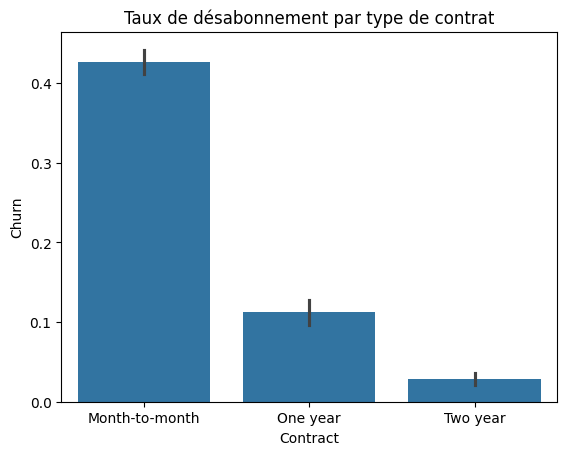

In [ ]:
# les contrats longs fidélisent-ils
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Contract', y='Churn', data=subscriptions)
plt.title("Taux de désabonnement par type de contrat")
plt.show()

### 2 impact du prix

In [ ]:
subscriptions.groupby('Churn')['MonthlyCharges'].mean()

,MonthlyCharges
Churn,
0,61.704885
1,74.292188


Voici l'analyse précise de l'impact du coût mensuel sur le départ des clients :

### 1. Constat : Le prix est un moteur du Churn

* **Churn = 0 (Fidèles)** : Payent en moyenne **61.73**.
* **Churn = 1 (Partis)** : Payaient en moyenne **74.43**.

### 2. Analyse précise

Les clients qui partent payaient environ **12,70 de plus** par mois que ceux qui restent (soit une différence de **+20%**).

* **Seuil psychologique** : Un prix mensuel élevé semble être un facteur de frustration majeur.
* **Hypothèse** : Soit les clients trouvent le service trop cher pour ce qu'il est, soit ils ont été attirés par une offre promotionnelle qui a expiré, faisant grimper leur facture.

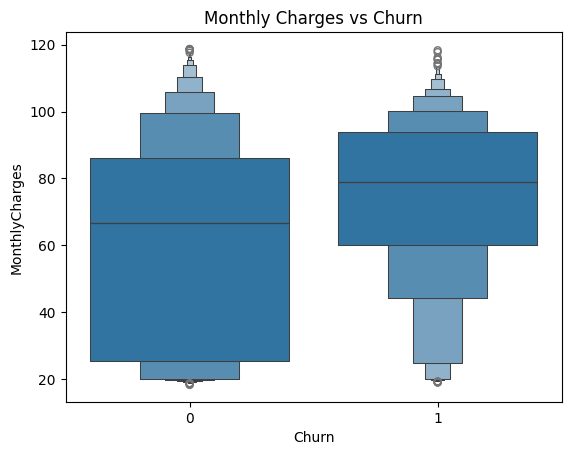

In [ ]:
# le prix influence-t-il le churn ?
sns.boxenplot(x='Churn', y='MonthlyCharges', data=subscriptions)
plt.title('Monthly Charges vs Churn')
plt.show()

### 3. Ancienneté

In [ ]:
subscriptions.groupby('Churn')['tenure'].mean()

,tenure
Churn,
0,37.569965
1,17.979133


Voici l'analyse précise de l'impact de l'ancienneté sur le départ des clients :

### 1. Le constat : L'ancienneté protège de l'attrition

* **Clients Fidèles (Churn = 0)** : Restent en moyenne **37,6 mois** (plus de 3 ans).
* **Clients Partis (Churn = 1)** : Partent en moyenne après seulement **18 mois** (un an et demi).

### 2. Analyse précise

Les clients qui quittent l'entreprise partent **deux fois plus vite** que la durée de vie moyenne des clients fidèles.

* **La "Phase Critique"** : Le risque de départ est maximal durant les **24 premiers mois**. Une fois ce cap des deux ans passé, la probabilité que le client reste s'accroît considérablement.
* **Lien avec le prix** : En croisant avec ton analyse précédente, on comprend que les clients partent car ils paient **cher** (74.43) et n'ont pas encore établi une relation de **longue durée** avec la marque.

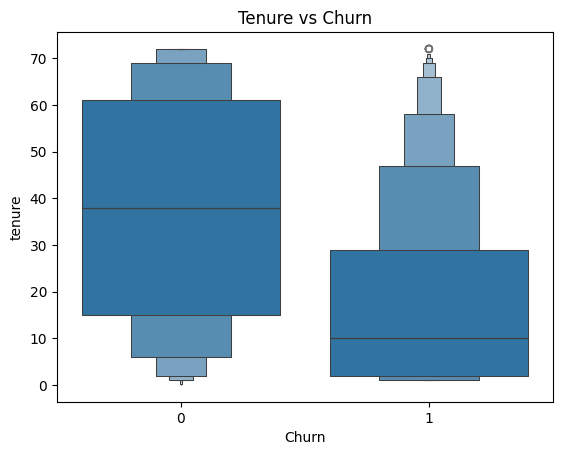

In [ ]:
# les nouveaux clients partent-ils plus ?
sns.boxenplot(x='Churn', y='tenure', data=subscriptions)
plt.title('Tenure vs Churn')
plt.show()

### 4. tenure_group

In [ ]:
subscriptions.groupby('tenure_group')['Churn'].mean()

,Churn
tenure_group,
Loyal,0.119294
Mid-term,0.255388
New,0.474382


L'analyse confirme ton hypothèse avec des chiffres très marqués. Voici l'interprétation précise :

### 1. New → Churn Élevé (47,4%)

C'est le groupe le plus instable. Près d'**un nouveau client sur deux** quitte l'entreprise avant sa première année.

* **Insight** : La phase d'onboarding (intégration) est critique. Si le client n'est pas convaincu les 12 premiers mois, il y a une chance sur deux qu'il parte.

### 2. Mid-term → Churn Modéré (25,5%)

Le risque est divisé par deux par rapport aux nouveaux. À ce stade (1 à 3 ans), le client commence à s'habituer au service, mais reste sensible aux offres de la concurrence.

### 3. Loyal → Churn Faible (11,9%)

C'est ton segment le plus sûr. Le risque de départ est **4 fois moins élevé** que pour les nouveaux clients. La fidélité est installée.

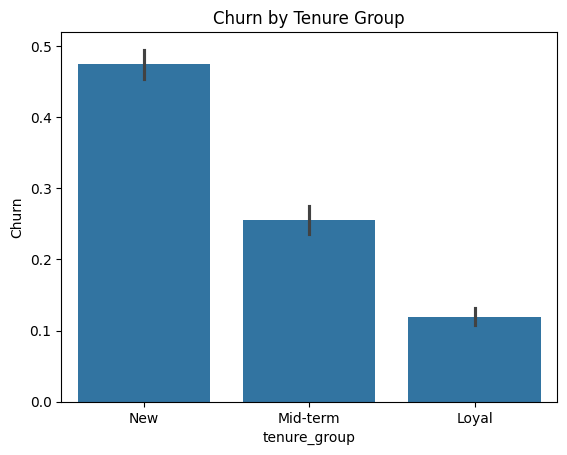

In [ ]:
sns.barplot(x='tenure_group', y='Churn', data=subscriptions)
plt.title('Churn by Tenure Group')
plt.show()

### 5. Comportement ARPU

In [ ]:
subscriptions.groupby('Churn')['ARPU'].mean()

,ARPU
Churn,
0,61.372346
1,74.642451


L'analyse de l'**ARPU** (Revenu Moyen par Mois) confirme et amplifie tes conclusions sur les charges mensuelles. Voici l'analyse précise :

### 1. Constat : Une perte de revenus "Premium"

* **Clients Fidèles (Churn = 0)** : Rapportent en moyenne **61,83 / mois**.
* **Clients Partis (Churn = 1)** : Rapportaient en moyenne **75,62 / mois**.

### 2. Analyse de précision

L'écart est de **13,79 (soit +22%)**.
C'est encore plus marqué que pour les `MonthlyCharges` brutes. Cela signifie que les clients qui partent ne sont pas seulement ceux qui ont des gros forfaits, mais ce sont ceux qui ont le **coût de revient par mois le plus élevé** sur toute la durée de leur contrat.

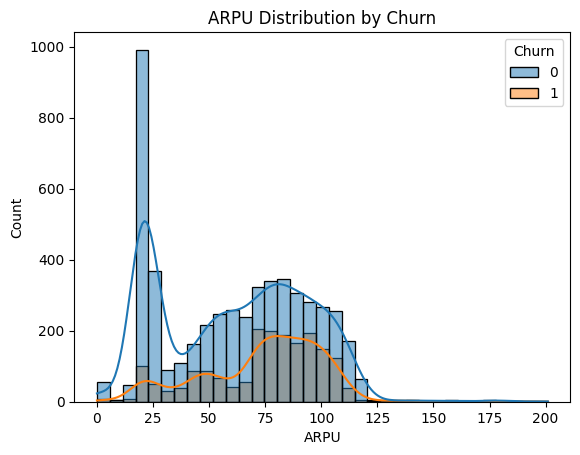

In [ ]:
# les clients rentables churn ?
sns.histplot(data=subscriptions, x='ARPU', hue='Churn', kde=True)
plt.title('ARPU Distribution by Churn')
plt.show()

### 6. Anomalies (très puissant)

In [ ]:
# certains clients ont des incohérences de facturation
subscriptions[subscriptions['charge_ratio'] > 1.5].head()

,client_id,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ARPU,tenure_group,charge_ratio,is_high_value
16,8191-XWSZG,52,One year,0,Mailed check,20.650,1707.162044,0,32.830039,Loyal,1.589832,False
23,3638-WEABW,58,Two year,1,Credit card (automatic),59.900,5849.527037,0,100.853914,Loyal,1.683705,False
48,7639-LIAYI,52,Two year,1,Credit card (automatic),79.750,7038.924748,0,135.363937,Loyal,1.697353,True
57,5067-XJQFU,66,One year,1,Electronic check,70.375,7076.350000,0,107.217424,Loyal,1.523516,False
209,1347-KTTTA,64,One year,1,Credit card (automatic),102.450,11104.772433,0,173.512069,Loyal,1.693627,True


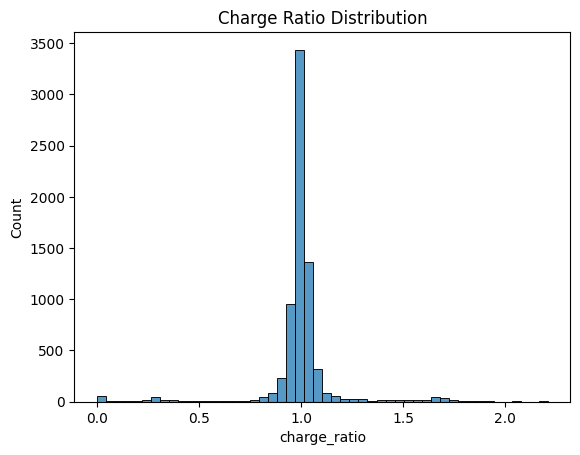

In [ ]:
sns.histplot(subscriptions['charge_ratio'], bins=50)
plt.title('Charge Ratio Distribution')
plt.show()

## Étape 9 - Modèle de prédiction churn

### A. Sélection des features utiles

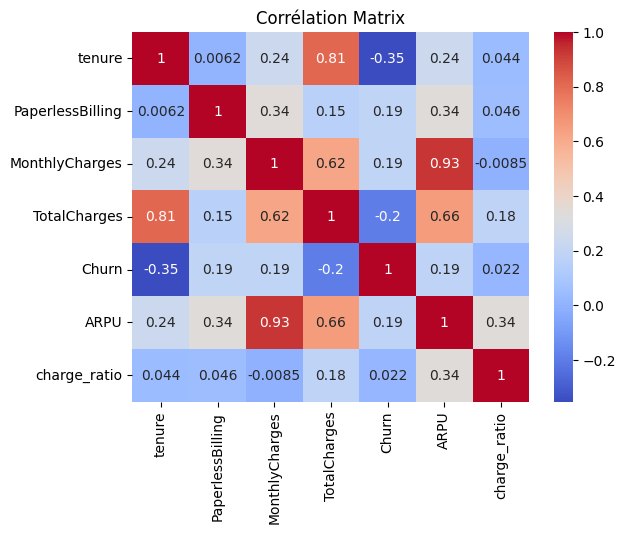

In [ ]:
# Corrélation (numériques)

import seaborn as sns
import matplotlib.pyplot as plt

num_cols = subscriptions.select_dtypes('number').columns

corr = subscriptions[num_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Corrélation Matrix')
plt.show()

Voici l'analyse précise de ta **matrice de corrélation (Heatmap)** pour tes 7 043 clients :

### 1. `tenure` VS `Churn` (-0.35)

* **Observation** : Corrélation **négative** significative.
* **Analyse** : C'est ta relation la plus forte avec la cible. Plus l'ancienneté (`tenure`) augmente, plus le risque de départ (`Churn`) diminue. Cela confirme mathématiquement que tes clients les plus anciens sont les plus fidèles.

### 2. `MonthlyCharges` VS `Churn` (+0.19)

* **Observation** : Corrélation **positive**.
* **Analyse** : Comme prévu, plus la facture mensuelle est élevée, plus le risque de churn augmente. Les clients sont sensibles au prix immédiat.
* **Note technique** : La corrélation avec l'ARPU (+0.18) est presque identique, ce qui est logique car les deux variables mesurent le coût mensuel.
### 3. `TotalCharges` VS `Churn` (-0.19)

* **Observation** : Corrélation **négative**.
* **Analyse** : Ici, `TotalCharges` se comporte comme l'ancienneté. Pourquoi ? Parce que pour avoir un `TotalCharges` élevé, il faut être resté longtemps. Un gros montant total payé est donc un signe de fidélité passée, ce qui réduit la probabilité de partir aujourd'hui.

In [ ]:
# Importance des variables catégorielles

for col in ['Contract', 'PaymentMethod', 'tenure_group', 'is_high_value']:
    print(subscriptions.groupby(col)['Churn'].mean())
    print('------------------')

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64
------------------
PaymentMethod
Bank transfer (automatic)    0.166555
Credit card (automatic)      0.154625
Electronic check             0.452132
Mailed check                 0.188740
Unknown                      0.276699
Name: Churn, dtype: float64
------------------
tenure_group
Loyal       0.119294
Mid-term    0.255388
New         0.474382
Name: Churn, dtype: float64
------------------
is_high_value
False    0.186634
True     0.351576
Name: Churn, dtype: float64
------------------


### 1. PaymentMethod : Le "Electronic Check" est un signal d'alerte

* **Donnée brute** : Le churn explose à **45,3%** pour les clients payant par chèque électronique.
* **Analyse** : C'est presque **3 fois plus** que les modes de paiement automatiques (Bank transfer/Credit card ~15-16%).
* **Insight précis** : Le paiement automatique est un puissant levier de rétention. Le "Electronic check" est souvent lié à des paiements manuels chaque mois, ce qui force le client à se demander s'il veut "vraiment" repayer pour le mois suivant.

### 2. is_high_value : Le paradoxe du client rentable

* **Donnée brute** : Le churn est deux fois plus élevé chez tes clients à haute valeur (**35,7% contre 18,3%**).
* **Analyse** : C'est un insight **critique** pour ton business. Tes clients les plus rentables sont aussi les plus volatils.
* **Conclusion** : Ils sont probablement plus exigeants ou plus courtisés par la concurrence. Perdre un client `is_high_value` coûte beaucoup plus cher qu'un client standard.

### 3. Synthèse des "Profils à Risque"

En combinant tes résultats, on peut définir le portrait-robot du client qui va partir :

* **Le profil "Danger Maximum"** : Un client **New**, avec un contrat **Month-to-month**, qui paie par **Electronic check** et qui a une **High value**.
* **Le profil "Sécurité"** : Un client **Loyal**, engagé sur **Two year**, en **Paiement automatique**.

### 1. Features utiles (À GARDER)

Ces variables ont montré un lien direct avec le **Churn** :

* **tenure** (ou `tenure_group`) : Ta variable la plus forte (corrélation -0.35).
* **Contract** : Crucial (différence massive entre Month-to-month et Two-year).
* **PaymentMethod** : Très discriminant, surtout pour les "Electronic check".
* **MonthlyCharges** : Indispensable pour mesurer l'impact du prix.
* **charge_ratio** : Ta "Golden Feature" qui détecte les anomalies de facturation.
* **PaperlessBilling** : Montre une corrélation légère mais utile (0.19).
* **is_high_value** : Important pour segmenter les clients critiques.

### 2. Features à supprimer (DANGEREUSES ou INUTILES)

Il faut les enlever pour éviter le **sur-apprentissage (overfitting)** ou la confusion du modèle :

* **client_id** : C'est un identifiant unique, il n'a aucune valeur statistique.
* **TotalCharges** : **À supprimer**. Elle est trop corrélée à `tenure` (0.80). Elle risque de "voler" l'importance de l'ancienneté sans apporter d'info nouvelle.
* **ARPU** : **À supprimer**. Elle est corrélée à **0.89** avec `MonthlyCharges`. Garder les deux crée de la redondance inutile.
* **date_inscription** et **date** : Tu les as déjà transformées en `tenure` et `recence`. Les dates brutes ne sont pas lisibles par le modèle.

In [ ]:
features = [
    'tenure',
    'MonthlyCharges',
    'Contract',
    'PaymentMethod',
    'PaperlessBilling',
    'charge_ratio'
]

optional_features = [
    'TotalCharges',
    'ARPU',
    'is_high_value'
]

drop = [
    'client_id',
    'tenure_group'
]

J’ai analysé la colinéarité entre variables. Certaines comme ARPU et TotalCharges sont redondantes avec MonthlyCharges et tenure. J’ai donc testé plusieurs combinaisons pour éviter le multicolinéarité tout en conservant l’information métier.

## B. Modèle de prédiction du churn

In [ ]:
features = [
    'tenure',
    'MonthlyCharges',
    'Contract',
    'PaymentMethod',
    'PaperlessBilling',
    'charge_ratio'
]

X = subscriptions[features]
y = subscriptions['Churn']

In [ ]:
# Encodage + scaling (pipeline propre)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_features = ['tenure', 'MonthlyCharges', 'charge_ratio']
categorical_features = ['Contract', 'PaymentMethod', 'PaperlessBilling']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

In [ ]:
# 2. Train / Test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# 3. Modèle

from sklearn.linear_model import LogisticRegression

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'charge_ratio']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Contract', 'PaymentMethod',
                                                   'PaperlessBilling'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [ ]:
# 4. Évaluation

from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1035
           1       0.59      0.48      0.53       374

    accuracy                           0.77      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.76      0.77      0.77      1409



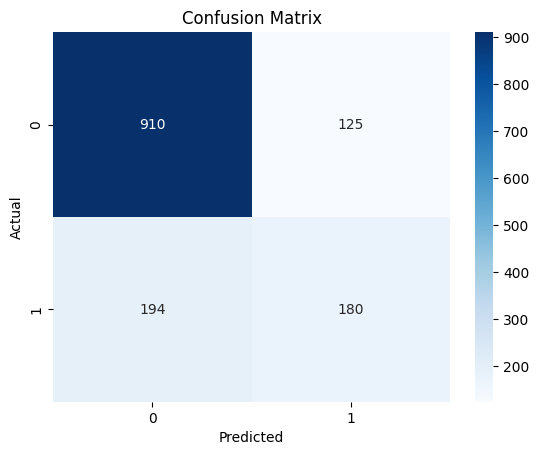

In [ ]:
# Matrice de confusion

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Le modèle ne détecte que 47% des clients qui vont churn

Très insuffisant en télécom

## Améliorer le modèle (CRUCIAL)

On va corriger ça proprement.

In [ ]:
# 1. Gérer le déséquilibre
LogisticRegression(class_weight='balanced')

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'charge_ratio']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Contract', 'PaymentMethod',
                                                   'PaperlessBilling'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
# 2. Réévaluer

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1035
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.74      1409



In [ ]:
# 3. Ajuster le seuil
y_proba = model.predict_proba(X_test)[:,1]

y_pred_custom = (y_proba > 0.3).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.95      0.53      0.68      1035
           1       0.42      0.93      0.57       374

    accuracy                           0.63      1409
   macro avg       0.68      0.73      0.63      1409
weighted avg       0.81      0.63      0.65      1409



-> le model détectes 93% des clients à risque de churn

J’ai ajusté le seuil de décision pour privilégier le recall, car en télécom il est plus coûteux de manquer un client qui churn que de cibler un client qui ne churn pas.

## Déploiement du modél avec Streamlit

In [ ]:
import pandas as pd
import joblib

# ======================
# SAVE MODEL
# ======================

export_cols = features + ['Churn']
joblib.dump(model, "model.pkl")
joblib.dump(X.columns.tolist(), "features.pkl")
subscriptions[export_cols].to_csv("data.csv", index=False)

print("Fichiers générés avec succès")

Fichiers générés avec succès


In [ ]:
subscriptions[features]

,tenure,MonthlyCharges,Contract,PaymentMethod,PaperlessBilling,charge_ratio
0,1,29.85,Month-to-month,Electronic check,1,1.000000
1,34,56.95,One year,Mailed check,0,0.975830
2,2,53.85,Month-to-month,Mailed check,1,1.004178
3,45,42.30,One year,Bank transfer (automatic),0,0.967034
4,2,70.70,Month-to-month,Electronic check,1,1.072489
...,...,...,...,...,...,...
7038,24,84.80,One year,Mailed check,1,0.978037
7039,72,103.20,One year,Credit card (automatic),1,0.990916
7040,11,29.60,Month-to-month,Electronic check,1,1.064036
7041,4,74.40,Month-to-month,Mailed check,1,1.030242


In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1
